# Création des CSV irradiance par node + graphe


In [1]:
# Creer les fichiers d'irradiance PVLIB/PVGIS par node
import re
import pandas as pd
import pvlib
from pathlib import Path

# Annee et source meteo/irradiance.
meteo_year = 2023
timezone = "Europe/Zurich"
raddatabase = "PVGIS-ERA5"

# Plan des panneaux: convention pvlib, 180 deg = sud.
surface_tilt = 60
surface_azimuth = 180

# ── Dossiers ──────────────────────────────────────────────────────────────────
data_dir = Path("Data")
data_dir.mkdir(exist_ok=True)

# Fichiers d'entree/sortie.
grid_file = data_dir / "87_0_grid.xlsx"
grid_id = "87_0"
node_file = data_dir / "nodes_valais.csv"
if not node_file.exists():
    raise FileNotFoundError("Impossible de trouver Data/nodes_valais.csv.")

# Long format: bus, time, datetime, latitude, longitude, irradiance_W_m2.
node_irradiance_file = data_dir / "irradiance_nodes_pvlib_hourly.csv"
# Une ligne par bus: irradiation moyenne et facteur moyen 0..1.
node_mean_file = data_dir / "irradiance_nodes_mean.csv"
# Profil moyen reseau, garde le format historique datetime, irradiance_W_m2.
irradiance_file = data_dir / "irradiance_pvlib_hourly.csv"

force_refresh_irradiance = False


def node_id_from_bus_name(name):
    match = re.search(r"_node_(.+)$", str(name))
    return match.group(1) if match else None


def id_to_str(value):
    try:
        return str(int(float(value)))
    except Exception:
        return str(value)


bus_df = pd.read_excel(grid_file, sheet_name="bus")
first_col = bus_df.columns[0]
if str(first_col).startswith("Unnamed"):
    bus_df = bus_df.rename(columns={first_col: "bus"})
else:
    bus_df = bus_df.reset_index().rename(columns={"index": "bus"})

bus_locations = bus_df[["bus", "name"]].copy()
bus_locations["bus"] = bus_locations["bus"].astype(int)
bus_locations["node_id"] = bus_locations["name"].apply(node_id_from_bus_name)

nodes_geo = pd.read_csv(node_file, encoding="utf-8-sig")
nodes_geo = nodes_geo[nodes_geo["grid_id"].astype(str) == grid_id].copy()
nodes_geo["node_id"] = nodes_geo["osmid"].apply(id_to_str)
nodes_geo["latitude"] = pd.to_numeric(nodes_geo["latitude"], errors="coerce")
nodes_geo["longitude"] = pd.to_numeric(nodes_geo["longitude"], errors="coerce")
nodes_geo = nodes_geo.dropna(subset=["latitude", "longitude"])

bus_locations = bus_locations.merge(
    nodes_geo[["node_id", "latitude", "longitude"]],
    on="node_id",
    how="left",
)
missing_locations = bus_locations[bus_locations[["latitude", "longitude"]].isna().any(axis=1)]
if len(missing_locations):
    display(missing_locations[["bus", "name", "node_id"]].head(20))
    raise ValueError("Certaines coordonnees de bus sont manquantes: verifier le mapping bus -> node dans nodes_valais.csv.")


def cache_is_valid(path, expected_year, expected_buses):
    if not path.exists():
        return False
    cached = pd.read_csv(path, usecols=["bus", "datetime"])
    if len(cached) != 8760 * len(expected_buses):
        return False
    cached_time = pd.to_datetime(cached["datetime"], errors="coerce")
    return (
        not cached_time.isna().any()
        and int(cached_time.iloc[0].year) == expected_year
        and set(cached["bus"].astype(int).unique()) == set(expected_buses)
    )


if force_refresh_irradiance or not cache_is_valid(node_irradiance_file, meteo_year, bus_locations["bus"].tolist()):
    hourly_tables = []
    for row_number, row in bus_locations.sort_values("bus").reset_index(drop=True).iterrows():
        bus = int(row["bus"])
        latitude = float(row["latitude"])
        longitude = float(row["longitude"])
        print(f"PVGIS bus {bus} ({row_number + 1}/{len(bus_locations)}) lat={latitude:.5f}, lon={longitude:.5f}")
        try:
            pv_weather, _ = pvlib.iotools.get_pvgis_hourly(
                latitude=latitude,
                longitude=longitude,
                start=meteo_year,
                end=meteo_year,
                raddatabase=raddatabase,
                components=True,
                surface_tilt=surface_tilt,
                surface_azimuth=surface_azimuth,
                usehorizon=True,
                pvcalculation=False,
                timeout=60,
            )
        except Exception as exc:
            raise RuntimeError(
                f"Impossible de recuperer les donnees PVGIS pour {meteo_year}. "
                "PVGIS-ERA5/PVGIS-SARAH3 ne fournissent souvent les donnees horaires que jusqu'a 2023. "
                "Pour une vraie meteo 2025, il faudra utiliser une autre source meteo, puis garder le meme "
                "format CSV: bus,time,datetime,latitude,longitude,irradiance_W_m2."
            ) from exc

        pv_weather.index = pd.to_datetime(pv_weather.index, utc=True).tz_convert(timezone)
        if (pv_weather.index.minute == 30).all():
            pv_weather.index = pv_weather.index - pd.Timedelta(minutes=30)
        pv_weather = pv_weather[~pv_weather.index.duplicated(keep="first")].sort_index()

        poa_cols = ["poa_direct", "poa_sky_diffuse", "poa_ground_diffuse"]
        irradiance = pv_weather[poa_cols].sum(axis=1).clip(lower=0)
        hourly_tables.append(pd.DataFrame({
            "bus": bus,
            "time": range(len(irradiance)),
            "datetime": irradiance.index.tz_localize(None),
            "latitude": latitude,
            "longitude": longitude,
            "irradiance_W_m2": irradiance.values,
        }))

    node_irradiance = pd.concat(hourly_tables, ignore_index=True)
    node_irradiance.to_csv(node_irradiance_file, index=False)
else:
    node_irradiance = pd.read_csv(node_irradiance_file, parse_dates=["datetime"])

duplicate_count = int(node_irradiance.duplicated(subset=["bus", "time"]).sum())
if duplicate_count:
    print(f"Doublons bus/time detectes dans l'irradiance: {duplicate_count}. Moyenne des doublons appliquee.")
    node_irradiance = (
        node_irradiance
        .groupby(["bus", "time"], as_index=False)
        .agg(
            datetime=("datetime", "first"),
            latitude=("latitude", "first"),
            longitude=("longitude", "first"),
            irradiance_W_m2=("irradiance_W_m2", "mean"),
        )
        .sort_values(["bus", "time"])
    )
    node_irradiance.to_csv(node_irradiance_file, index=False)

if len(node_irradiance) != 8760 * len(bus_locations):
    raise ValueError(f"Irradiance attendue: {8760 * len(bus_locations)} lignes, obtenu: {len(node_irradiance)}")

node_mean = (
    node_irradiance
    .groupby(["bus", "latitude", "longitude"], as_index=False)
    .agg(
        irradiance_mean_W_m2=("irradiance_W_m2", "mean"),
        irradiance_max_W_m2=("irradiance_W_m2", "max"),
    )
)
node_mean["irradiance_mean_norm"] = (
    node_mean["irradiance_mean_W_m2"] / node_mean["irradiance_max_W_m2"].replace(0, pd.NA)
).fillna(0)
node_mean.to_csv(node_mean_file, index=False)

network_irradiance = (
    node_irradiance
    .groupby("datetime", as_index=False)["irradiance_W_m2"]
    .mean()
)
network_irradiance.to_csv(irradiance_file, index=False)

print(f"Fichier horaire par node: {node_irradiance_file}")
print(f"Fichier moyenne par node: {node_mean_file}")
print(f"Fichier moyen reseau: {irradiance_file}")
display(node_mean.head())

Fichier horaire par node: Data/irradiance_nodes_pvlib_hourly.csv
Fichier moyenne par node: Data/irradiance_nodes_mean.csv
Fichier moyen reseau: Data/irradiance_pvlib_hourly.csv


,bus,latitude,longitude,irradiance_mean_W_m2,irradiance_max_W_m2,irradiance_mean_norm
0,0,46.328807,8.024048,183.159231,1145.97,0.159829
1,1,46.329004,8.023794,183.159945,1145.99,0.159827
2,2,46.329291,8.024219,183.161178,1145.99,0.159828
3,3,46.328200,8.023194,183.287850,1145.96,0.159943
4,4,46.327000,8.023580,182.567412,1145.93,0.159318


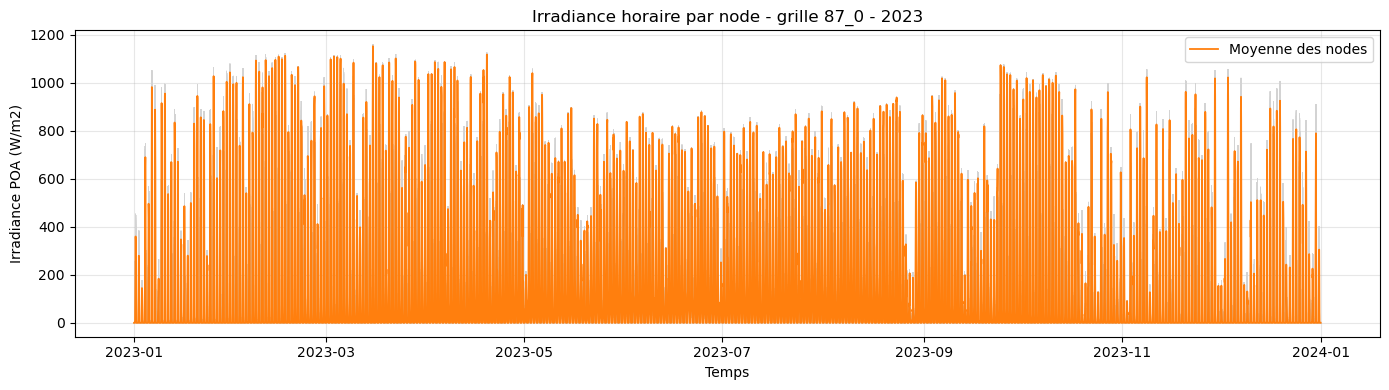

In [2]:
# Tracer l'irradiance horaire pour chaque node et la moyenne du reseau
import matplotlib.pyplot as plt

irradiance_pivot = (
    node_irradiance
    .pivot_table(index="datetime", columns="bus", values="irradiance_W_m2", aggfunc="mean")
    .sort_index()
)
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(irradiance_pivot.index, irradiance_pivot.values, color="lightgray", linewidth=0.45, alpha=0.45)
ax.plot(irradiance_pivot.index, irradiance_pivot.mean(axis=1), color="tab:orange", linewidth=1.3, label="Moyenne des nodes")
ax.set_title(f"Irradiance horaire par node - grille {grid_id} - {meteo_year}")
ax.set_xlabel("Temps")
ax.set_ylabel("Irradiance POA (W/m2)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()